# Outlier  Detection & Removal

> **1>import required Libraries & from libs  modules and  from modules  fun/mtd  which ever  you  need here + you want to use amiong existing ones** 

*Raw dataset
     ↓
Fresh pd.read_csv()
     ↓
original_rows = 70000
     ↓
Invalid BP removal
     ↓
BP relationship check
     ↓
IQR outlier removal
     ↓
Final cleaned dataset
     ↓
Save CSV*

In [48]:
import pandas as pd
import seaborn as sns
#  why   matplotlib.pyplot  bcz show() function belong to this  not  to  matplotlib directly
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
print("all libs are imported successfully !")

all libs are imported successfully !


** *2> load dataset and  injest it*** 

*Doubt*

*CSV means tabular data stored as text. The separator can be:

,   comma
;   semicolon
\t  tab* 
*and  default seperator of panda is ,   and here our  CVD file was created/exported using semicolon ; as the delimiter. i.e    now panda is  using , as default seperator  but  actual one  is ; as per our df   thats why we are using here sep=";"  along with dataset injestion*

In [49]:
dataset = pd.read_csv("/kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv",sep=";")
print("dataset is injested successfully !")

# checking dataset before removal 
original_rows = dataset.shape[0]

print("Original number of rows:", original_rows)

dataset is injested successfully !
Original number of rows: 70000


*Normal Visualisation of data / not EDA*

In [50]:
dataset.head(3)
# dataset.tail(3)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1


*ALL stuffs below  is for  OUTLIER Detection only*

In [51]:
#1 info() function se  sara  total entries, no. of rows,columns/features  sab  aa jayega     just  by  info( ) function
dataset.info()

print(" ")
print(" ")
print(" ")

# dataset.describe() ka use dataset ke
# numerical columns ka statistical summary dekhne ke liye hai.
# Ye mainly ye values deta hai:
# count → kitne non-null values hain
# mean → average
# std → data kitna spread hai
# min → minimum value
# 25% → first quartile
# 50% → median
# 75% → third quartile
# max → maximum value
dataset.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
 
 
 


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


*3> check/identify   OUTLIERS* 
* MTD1->boxplot of  seaborn ---> is  used for seeing  outliers in our datset*
* MTD2->distplot  can also be used --->  direclty nahi batata outlier but ham  extended tail ke acc pata akr  skaten ki yes outlier hai

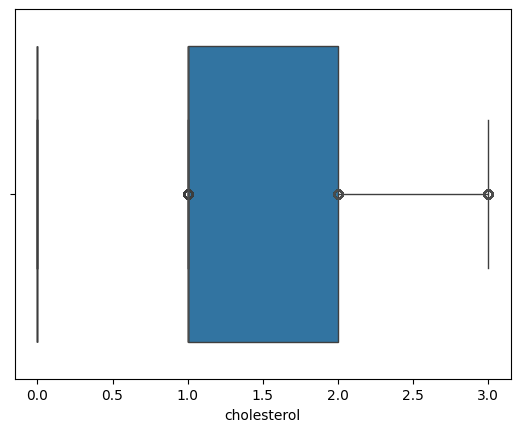

 see,  above graphs are  overlaping so plot is just one    but  below ones are seprately !






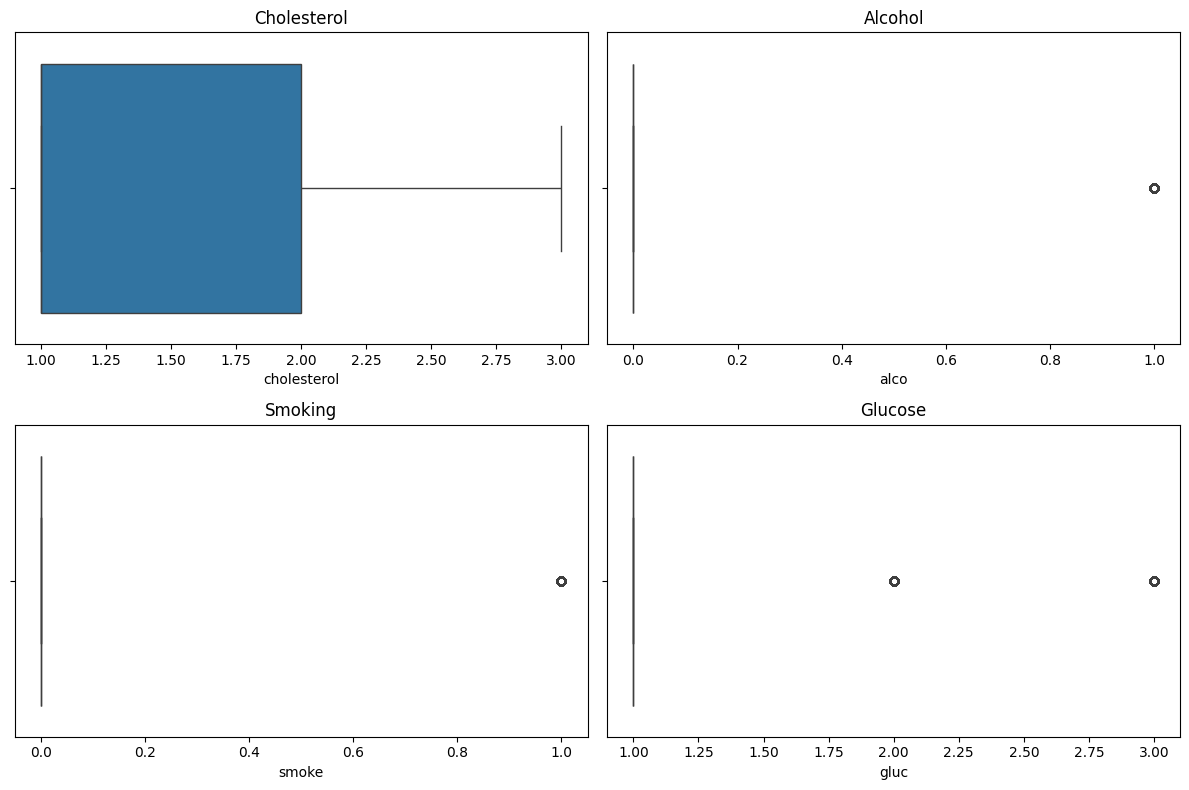

In [52]:
# MTD1-> boxplot for ploting outliers  its syntax is below

# these all 4  will  overlap each other as they all are 
# There is only one current figure/axes, so Seaborn keeps adding plots to the same place.
# Since these are categorical/binary features, they can overlap and you may visually see only one.

sns.boxplot(x="cholesterol",data=dataset)
sns.boxplot(x="alco",data=dataset)
sns.boxplot(x="smoke",data=dataset)
sns.boxplot(x="gluc",data=dataset)
plt.show()


print(" see,  above graphs are  overlaping so plot is just one    but  below ones are seprately !")

print("")
print("")
print("")
print("")
#   if  you have  to  see plots  single-silgle seperately and  code must be written in same  block  then  use this code  
# Import Matplotlib's pyplot module for creating and displaying plots
import matplotlib.pyplot as plt

# Import Seaborn for statistical data visualization
import seaborn as sns


# Create a figure with width = 12 inches and height = 8 inches
plt.figure(figsize=(12, 8))


# Create the first subplot in a 2 rows × 2 columns layout
plt.subplot(2, 2, 1)

# Create a boxplot for the cholesterol feature
sns.boxplot(x="cholesterol", data=dataset)

# Add a title to the first plot
plt.title("Cholesterol")


# Create the second subplot
plt.subplot(2, 2, 2)

# Create a boxplot for the alcohol consumption feature
sns.boxplot(x="alco", data=dataset)

# Add a title to the second plot
plt.title("Alcohol")


# Create the third subplot
plt.subplot(2, 2, 3)

# Create a boxplot for the smoking feature
sns.boxplot(x="smoke", data=dataset)

# Add a title to the third plot
plt.title("Smoking")


# Create the fourth subplot
plt.subplot(2, 2, 4)

# Create a boxplot for the glucose level feature
sns.boxplot(x="gluc", data=dataset)

# Add a title to the fourth plot
plt.title("Glucose")


# Automatically adjust spacing between the four subplots
plt.tight_layout()

# Display all four plots together
plt.show()

**MTD2--->Distribution plot**

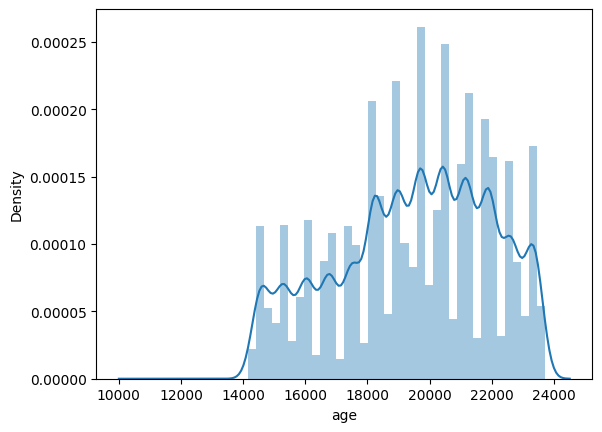

In [53]:
sns.distplot(dataset["age"])
plt.show()

**as above plot is  x-axis : age in days (not in yrs)  y-axis=    so 
# Convert age from days to years
dataset["age"] = (dataset["age"] / 365).round(1)  using this**

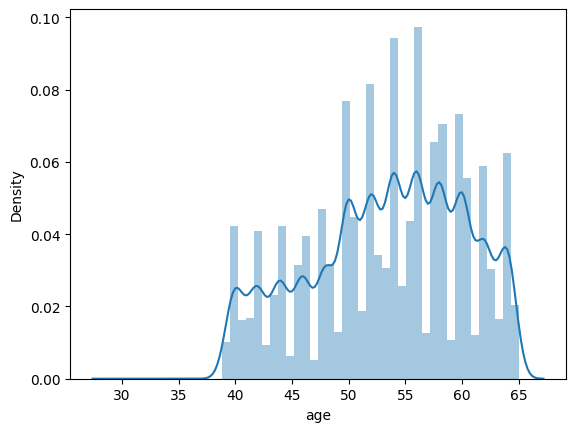

In [54]:
#step1 Convert age from days to years
dataset["age"] = (dataset["age"] / 365).round(1)

# step2    show  distribution plot  by  librairy   matplotlib.pyplot
# Plot age distribution
sns.distplot(dataset["age"])

plt.show()

# removal


In [55]:
# STEP 3: Check invalid blood-pressure values

invalid_bp = dataset[
    (dataset["ap_hi"] <= 0) |
    (dataset["ap_lo"] <= 0)
]

print("Invalid BP rows:", invalid_bp.shape[0])

# STEP 4: Remove clinically invalid BP values

dataset = dataset[
    (dataset["ap_hi"] > 0) &
    (dataset["ap_lo"] > 0)
].copy()



# STEP 5: Remove logically invalid BP relationships
# ap_hi should normally be greater than ap_lo

invalid_bp_relation = dataset[
    dataset["ap_hi"] <= dataset["ap_lo"]
]

print("Invalid BP relationship rows:",
      invalid_bp_relation.shape[0])

dataset = dataset[
    dataset["ap_hi"] > dataset["ap_lo"]
].copy()




# STEP 6: Detect and remove statistical outliers using IQR

outlier_features = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

for feature in outlier_features:

    Q1 = dataset[feature].quantile(0.25)
    Q3 = dataset[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    before = dataset.shape[0]

    dataset = dataset[
        (dataset[feature] >= lower_bound) &
        (dataset[feature] <= upper_bound)
    ].copy()

    after = dataset.shape[0]

    print(
        feature,
        "->",
        before - after,
        "outliers removed"
    )





# STEP 7: Compare dataset before and after outlier removal

cleaned_rows = dataset.shape[0]

print("\n OUTLIER REMOVAL SUMMARY ")
print("Original rows :", original_rows)
print("Cleaned rows  :", cleaned_rows)
print("Rows removed  :", original_rows - cleaned_rows)
print(" ")






# Check final dataset information

dataset.info()

# Check statistical summary after cleaning

dataset.describe()

Invalid BP rows: 29
Invalid BP relationship rows: 1229
age -> 4 outliers removed
height -> 506 outliers removed
weight -> 1686 outliers removed
ap_hi -> 948 outliers removed
ap_lo -> 3099 outliers removed

 OUTLIER REMOVAL SUMMARY 
Original rows : 70000
Cleaned rows  : 62499
Rows removed  : 7501
 
<class 'pandas.core.frame.DataFrame'>
Index: 62499 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           62499 non-null  int64  
 1   age          62499 non-null  float64
 2   gender       62499 non-null  int64  
 3   height       62499 non-null  int64  
 4   weight       62499 non-null  float64
 5   ap_hi        62499 non-null  int64  
 6   ap_lo        62499 non-null  int64  
 7   cholesterol  62499 non-null  int64  
 8   gluc         62499 non-null  int64  
 9   smoke        62499 non-null  int64  
 10  alco         62499 non-null  int64  
 11  active       62499 non-null  int64  
 12  card

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,62499.000000,62499.000000,62499.000000,62499.000000,62499.000000,62499.000000,62499.000000,62499.000000,62499.000000,62499.000000,62499.000000,62499.000000,62499.000000
mean,49942.397878,53.407992,1.348550,164.405478,73.180473,126.421847,81.698267,1.357734,1.220660,0.086337,0.052161,0.804333,0.493896
std,28864.728376,6.734342,0.476515,7.530966,12.271325,14.288637,7.672536,0.675215,0.567613,0.280864,0.222353,0.396717,0.499967
min,0.000000,39.100000,1.000000,143.000000,40.000000,90.000000,65.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,24877.000000,48.600000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,49981.000000,54.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74852.500000,58.500000,2.000000,170.000000,81.000000,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,65.000000,2.000000,186.000000,107.000000,170.000000,105.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


# Finally cleaned dataset saving

In [56]:
dataset.to_csv(
    "cardio_cleanedDataSet.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [59]:
# Verify the saved cleaned dataset

cleaned_dataset = pd.read_csv("cardio_cleanedDataSet.csv")

print("Cleaned dataset loaded successfully!")
print("Shape:", cleaned_dataset.shape)

print(cleaned_dataset.isnull().sum())
cleaned_dataset.head(3)

Cleaned dataset loaded successfully!
Shape: (62499, 13)
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.4,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55.4,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51.7,1,165,64.0,130,70,3,1,0,0,0,1
